# TCC — Análise exploratória dos dados sintéticos Google Meridian
Etapa 1: compreender, auditar e preparar dados geo-temporais. Não estima efeitos causais.

Base principal: `geo_all_channels.csv`. Comparações: `geo_media.csv` e `geo_media_rf.csv`.
São cenários sintéticos diferentes: não juntar registros nem comparar KPIs como se fossem a mesma empresa.
O notebook é independente do pacote Meridian e roda em CPU no Colab com pandas, numpy e matplotlib.
Fonte fixada por commit; o primeiro carregamento usa os arquivos locais quando disponíveis ou baixa os CSVs oficiais.

Pergunta do TCC: como um MMM Bayesiano hierárquico permite estimar efeitos de mídia e apoiar alocação em dados geo-temporais? A EDA estabelece a adequação dos dados e as limitações de identificação antes da inferência.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import hashlib, json, platform, urllib.request
from IPython.display import display
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True, 'grid.alpha': .2})
pd.set_option('display.max_columns', 30)
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else (Path.cwd().parent if (Path.cwd().parent / 'data').exists() else Path.cwd() / 'meridian_eda')
DATA = ROOT / 'data'; OUT = ROOT / 'reports' / 'eda'
DATA.mkdir(parents=True, exist_ok=True); OUT.mkdir(parents=True, exist_ok=True)
UPSTREAM_COMMIT = '58ea51bb6225717fce55949ae02708308ce0e090'
BASE_URL = f'https://raw.githubusercontent.com/google/meridian/{UPSTREAM_COMMIT}/meridian/data/simulated_data/csv/'
datasets = {}; provenance = {}
for name in ['geo_all_channels', 'geo_media', 'geo_media_rf']:
    path = DATA / f'{name}.csv'
    if not path.exists():
        with urllib.request.urlopen(BASE_URL + path.name, timeout=60) as response:
            path.write_bytes(response.read())
    raw = path.read_bytes()
    datasets[name] = pd.read_csv(path).drop(columns=['Unnamed: 0'], errors='ignore')
    datasets[name]['time'] = pd.to_datetime(datasets[name]['time'], format='%Y-%m-%d', errors='raise')
    provenance[name] = {'url': BASE_URL + path.name, 'sha256': hashlib.sha256(raw).hexdigest()}
versions = {'python': platform.python_version(), 'pandas': pd.__version__, 'numpy': np.__version__, 'upstream_commit': UPSTREAM_COMMIT, 'sources': provenance}
(OUT / 'provenance.json').write_text(json.dumps(versions, indent=2))
df = datasets['geo_all_channels'].sort_values(['geo', 'time']).reset_index(drop=True)
paid = [c for c in df if c.startswith('Channel') and c.endswith('_impression')]
spend = [c.replace('_impression', '_spend') for c in paid]
controls = [c for c in df if c.endswith('_control')]
organic = ['Organic_channel0_impression']
print('Versões:', versions['python'], versions['pandas'], versions['numpy'])
def table(frame, filename):
    frame.to_csv(OUT / (filename + '.csv'), index=True)
    display(frame)
def show(name):
    plt.tight_layout(); plt.savefig(OUT / (name + '.png'), dpi=160, bbox_inches='tight'); plt.show(); plt.close()


Versões: 3.12.14 2.2.3 2.3.5


## 1. Inventário e dicionário
Cada linha representa uma região em uma semana. As 6.240 linhas do painel principal não são 6.240 observações independentes: regiões compartilham condições de mercado e semanas têm dependência temporal.

`conversions` é o KPI, não receita. Receita sintética por linha = conversions × revenue_per_conversion; some esses produtos, em vez de multiplicar totais por uma média simples.
As unidades monetárias não estão identificadas no CSV; não atribuímos reais, euros ou dólares.
Os nomes Channel0–Channel4 não identificam TV, Search ou Social. Os controles são escores sintéticos; valores negativos não são vendas negativas. `Promo` é intensidade contínua, não uma flag binária.


In [2]:
inventory = pd.DataFrame([{'base': name, 'linhas': len(d), 'colunas_uteis': len(d.columns), 'regioes': d.geo.nunique(), 'semanas': d.time.nunique(), 'inicio': d.time.min(), 'fim': d.time.max(), 'nulos': int(d.isna().sum().sum()), 'duplicatas_geo_time': int(d.duplicated(['geo', 'time']).sum())} for name, d in datasets.items()]).set_index('base')
table(inventory, 'inventario')
def role(c):
    if c in ['geo','time']: return 'coordenada'
    if c == 'conversions': return 'KPI não monetário'
    if c == 'revenue_per_conversion': return 'valor monetário por unidade do KPI'
    if c == 'population': return 'escala regional; constante no tempo'
    if c in controls: return 'controle sintético; mecanismo causal não documentado no CSV'
    if c == 'Promo': return 'tratamento não mídia; intensidade contínua'
    if c.startswith('Organic'): return 'exposição orgânica; sem gasto informado'
    return 'gasto pago' if c.endswith('_spend') else 'exposição paga'
table(pd.DataFrame([{'coluna':c, 'papel':role(c), 'tipo':str(df[c].dtype), 'valores_distintos':df[c].nunique()} for c in df]).set_index('coluna'), 'dicionario')


,linhas,colunas_uteis,regioes,semanas,inicio,fim,nulos,duplicatas_geo_time
base,,,,,,,,
geo_all_channels,6240,19,40,156,2021-01-25,2024-01-15,0,0
geo_media,3120,15,20,156,2021-01-25,2024-01-15,0,0
geo_media_rf,3120,17,20,156,2021-01-25,2024-01-15,0,0


,papel,tipo,valores_distintos
coluna,,,
geo,coordenada,object,40
time,coordenada,datetime64[ns],156
Channel0_impression,exposição paga,int64,5483
Channel1_impression,exposição paga,int64,4491
Channel2_impression,exposição paga,int64,2226
Channel3_impression,exposição paga,int64,6069
Channel4_impression,exposição paga,int64,5416
competitor_sales_control,controle sintético; mecanismo causal não docum...,float64,6240
sentiment_score_control,controle sintético; mecanismo causal não docum...,float64,6239


## 2. Auditoria de qualidade e suporte
Verificamos chaves, painel completo, cadência semanal, valores finitos, domínios, população constante e alinhamento entre exposição e gasto. Zeros de mídia podem representar pausas; não os imputamos. Extremos pela regra IQR são alertas descritivos, não exclusões automáticas. Removemos apenas a coluna de índice exportado `Unnamed: 0`.


In [3]:
audit = []
for name, d in datasets.items():
    grid = pd.MultiIndex.from_product([d.geo.unique(), sorted(d.time.unique())], names=['geo', 'time'])
    observed = pd.MultiIndex.from_frame(d[['geo','time']])
    gaps = d.sort_values(['geo','time']).groupby('geo').time.diff().dropna().dt.days
    numeric = d.select_dtypes('number')
    domain = [c for c in numeric if not c.endswith('_control')]
    audit.append({'base':name, 'faltam_geo_semanas':len(grid.difference(observed)), 'cadencia_7_dias':bool(gaps.eq(7).all()), 'nao_finitos':int((~np.isfinite(numeric)).sum().sum()), 'negativos_fora_controles':int(numeric[domain].lt(0).sum().sum()), 'populacao_positiva':bool(d.population.gt(0).all()), 'max_populacoes_por_geo':int(d.groupby('geo').population.nunique().max())})
table(pd.DataFrame(audit).set_index('base'), 'auditoria')
assert not df.duplicated(['geo','time']).any()
assert len(df) == df.geo.nunique()*df.time.nunique()
assert np.isfinite(df.select_dtypes('number')).all().all()
assert df.population.gt(0).all()
num = df.select_dtypes('number')
q1, q3 = num.quantile(.25), num.quantile(.75); iqr=q3-q1
quality = pd.DataFrame({'nulos':num.isna().sum(), 'zeros_pct':num.eq(0).mean()*100, 'negativos':num.lt(0).sum(), 'extremos_IQR':((num.lt(q1-1.5*iqr)) | (num.gt(q3+1.5*iqr))).sum(), 'constante':num.nunique().le(1)})
table(quality, 'qualidade_colunas')
table(num.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T, 'estatisticas')
print('Conversões fracionárias (%):', 100*df.conversions.mod(1).ne(0).mean())
print('Conversões/população: intervalo', (df.conversions/df.population).min(), (df.conversions/df.population).max())
print('Isso não é probabilidade individual de conversão nem contagem de clientes únicos.')


Conversões fracionárias (%): 25.080128205128204
Conversões/população: intervalo 2.4223737831985184 44.13332126220485
Isso não é probabilidade individual de conversão nem contagem de clientes únicos.


,faltam_geo_semanas,cadencia_7_dias,nao_finitos,negativos_fora_controles,populacao_positiva,max_populacoes_por_geo
base,,,,,,
geo_all_channels,0,True,0,0,True,1
geo_media,0,True,0,0,True,1
geo_media_rf,0,True,0,0,True,1


,nulos,zeros_pct,negativos,extremos_IQR,constante
Channel0_impression,0,12.099359,0,164,False
Channel1_impression,0,27.916667,0,215,False
Channel2_impression,0,64.262821,0,941,False
Channel3_impression,0,2.708333,0,108,False
Channel4_impression,0,13.141026,0,143,False
competitor_sales_control,0,0.000000,3238,61,False
sentiment_score_control,0,0.000000,3216,61,False
Channel0_spend,0,12.099359,0,164,False
Channel1_spend,0,27.916667,0,215,False
Channel2_spend,0,64.262821,0,941,False


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Channel0_impression,6240.0,8.851635e+05,8.193451e+05,0.000000,0.000000e+00,0.000000e+00,2.536458e+05,6.796705e+05,1.324174e+06,2.527659e+06,3.458104e+06,5.192032e+06
Channel1_impression,6240.0,5.206055e+05,6.206231e+05,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.106525e+05,8.075525e+05,1.825046e+06,2.604638e+06,4.397540e+06
Channel2_impression,6240.0,2.605050e+05,5.551842e+05,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.547340e+05,1.425716e+06,2.614613e+06,5.610156e+06
Channel3_impression,6240.0,1.806810e+06,1.304818e+06,0.000000,0.000000e+00,1.685678e+05,8.083565e+05,1.505379e+06,2.566118e+06,4.282816e+06,5.741465e+06,7.635147e+06
Channel4_impression,6240.0,9.816780e+05,9.141768e+05,0.000000,0.000000e+00,0.000000e+00,2.675945e+05,7.462475e+05,1.476708e+06,2.788040e+06,3.776702e+06,6.975542e+06
competitor_sales_control,6240.0,-4.441200e-02,1.210164e+00,-4.825634,-2.819445e+00,-1.995962e+00,-8.727362e-01,-5.034648e-02,7.436329e-01,1.987068e+00,2.869632e+00,3.924682e+00
sentiment_score_control,6240.0,-3.367510e-02,1.175572e+00,-4.230392,-2.818955e+00,-1.940917e+00,-8.080845e-01,-3.643259e-02,7.393907e-01,1.891985e+00,2.756426e+00,4.320259e+00
Channel0_spend,6240.0,6.490659e+03,6.008031e+03,0.000000,0.000000e+00,0.000000e+00,1.859914e+03,4.983836e+03,9.709803e+03,1.853463e+04,2.535732e+04,3.807173e+04
Channel1_spend,6240.0,5.019279e+03,5.983571e+03,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.995073e+03,7.785801e+03,1.759569e+04,2.511192e+04,4.239770e+04
Channel2_spend,6240.0,1.935793e+03,4.125532e+03,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.892909e+03,1.059439e+04,1.942899e+04,4.168864e+04


## 3. Investimento, exposição e custo
CPM = 1.000 × soma(gasto)/soma(impressões). É um custo observado, não ROI.
A razão receita total/gasto total descreve o conjunto de receitas, inclusive baseline, promoções e mídia orgânica; não mede retorno incremental de publicidade.
Uma relação praticamente determinística entre gasto e impressões indica preços artificiais constantes. Não inclua ambos como regressoras independentes para o mesmo canal.


Receita sintética total: 1318699437.7351665
Gasto total: 219492402.35048595


,gasto,impressions,participacao_gasto_pct,zero_exposicao_pct,zero_inconsistente,CPM_ponderado,CV_CPM_ativo,corr_gasto_exposicao
canal,,,,,,,,
Channel0,4.050171e+07,5523420467,18.452444,12.099359,0,7.332723,3.319006e-08,1.0
Channel1,3.132030e+07,3248578573,14.269422,27.916667,0,9.641232,3.347351e-08,1.0
Channel2,1.207935e+07,1625551369,5.503311,64.262821,0,7.430924,3.476105e-08,1.0
Channel3,8.786036e+07,11274497204,40.028884,2.708333,0,7.792840,3.313267e-08,1.0
Channel4,4.773068e+07,6125670562,21.745939,13.141026,0,7.791912,3.309852e-08,1.0


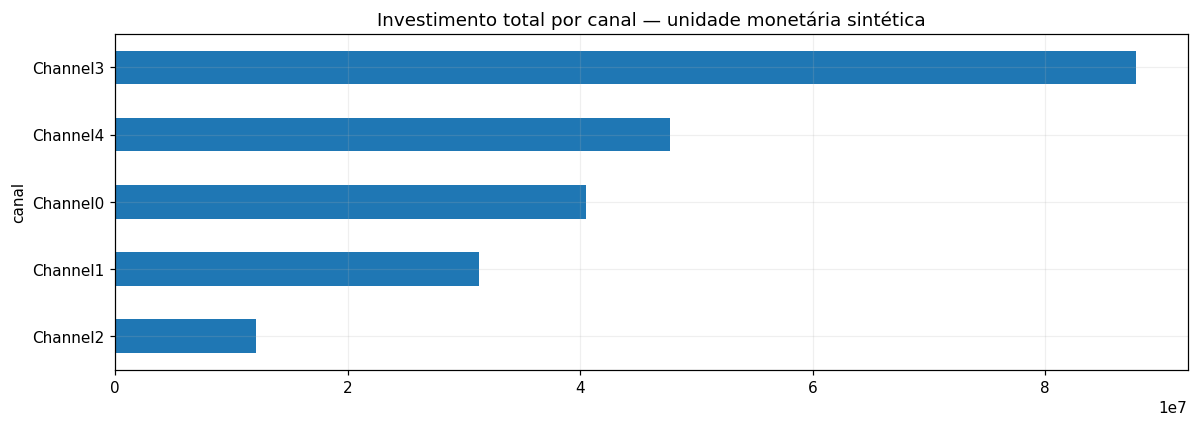

In [4]:
df['receita_sintetica'] = df.conversions*df.revenue_per_conversion
df['gasto_total'] = df[spend].sum(axis=1)
rows=[]
for imp, cost in zip(paid, spend):
    active=df[imp].gt(0); cpm=1000*df.loc[active,cost]/df.loc[active,imp]
    rows.append({'canal':imp.replace('_impression',''), 'gasto':df[cost].sum(), 'impressions':df[imp].sum(), 'participacao_gasto_pct':100*df[cost].sum()/df.gasto_total.sum(), 'zero_exposicao_pct':100*(~active).mean(), 'zero_inconsistente':int((df[imp].eq(0)!=df[cost].eq(0)).sum()), 'CPM_ponderado':1000*df[cost].sum()/df[imp].sum(), 'CV_CPM_ativo':cpm.std()/cpm.mean(), 'corr_gasto_exposicao':df[imp].corr(df[cost])})
channels=pd.DataFrame(rows).set_index('canal'); table(channels,'canais')
print('Receita sintética total:',df.receita_sintetica.sum())
print('Gasto total:',df.gasto_total.sum())
channels.gasto.sort_values().plot.barh(title='Investimento total por canal — unidade monetária sintética'); show('gasto_canais')


## 4. Tempo: tendência, variabilidade, calendário e dependência
Agregamos apenas grandezas aditivas (KPI, receita, gasto, impressões). A população é repetida semanalmente: para população nacional, some uma observação por região.
Índices base 100 permitem comparar movimentos sem confundir escalas. Perfis mensais são descritivos; três anos não confirmam sazonalidade estável. ACF e correlações defasadas não identificam adstock.


,count,mean,std,min,25%,50%,75%,max
conversions,156.0,4.226328e+08,2.921208e+07,3.402833e+08,4.053507e+08,4.227034e+08,4.404787e+08,4.912874e+08
receita_sintetica,156.0,8.453202e+06,5.839598e+05,6.805080e+06,8.112613e+06,8.453836e+06,8.813017e+06,9.828881e+06
gasto_total,156.0,1.407003e+06,4.265735e+05,4.198948e+05,1.139011e+06,1.355441e+06,1.660606e+06,2.965465e+06
Channel0_impression,156.0,3.540654e+07,1.213904e+07,7.851189e+06,2.704481e+07,3.496160e+07,4.495542e+07,6.386554e+07
Channel1_impression,156.0,2.082422e+07,1.020506e+07,2.729719e+06,1.340884e+07,1.937102e+07,2.684337e+07,5.236681e+07
Channel2_impression,156.0,1.042020e+07,9.106143e+06,0.000000e+00,3.297471e+06,8.122188e+06,1.566935e+07,4.608557e+07
Channel3_impression,156.0,7.227242e+07,2.228079e+07,1.796734e+07,5.635578e+07,7.085189e+07,8.414181e+07,1.402645e+08
Channel4_impression,156.0,3.926712e+07,1.602066e+07,6.971125e+06,2.745158e+07,3.773983e+07,4.983927e+07,8.370790e+07
Organic_channel0_impression,156.0,2.129867e+07,1.153309e+07,4.002560e+05,1.276210e+07,2.015750e+07,2.904241e+07,6.093443e+07


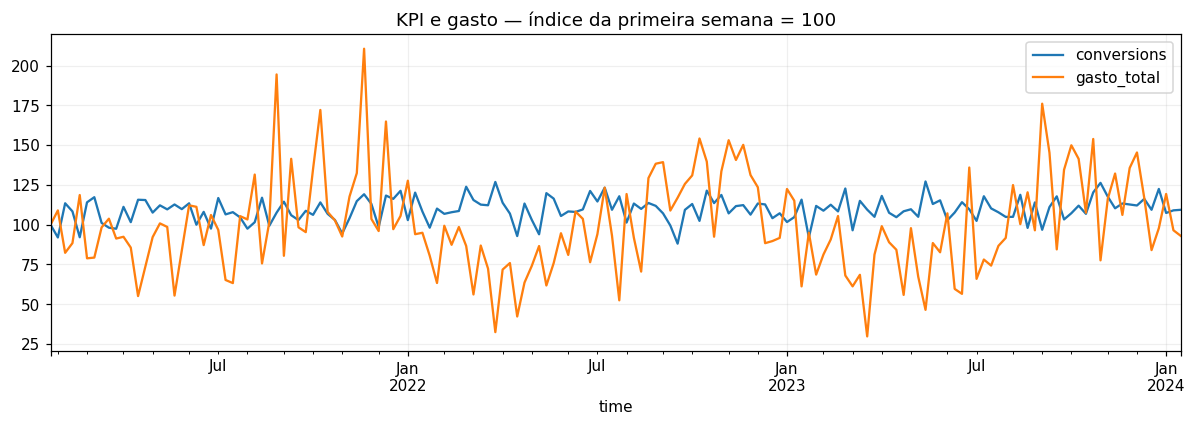

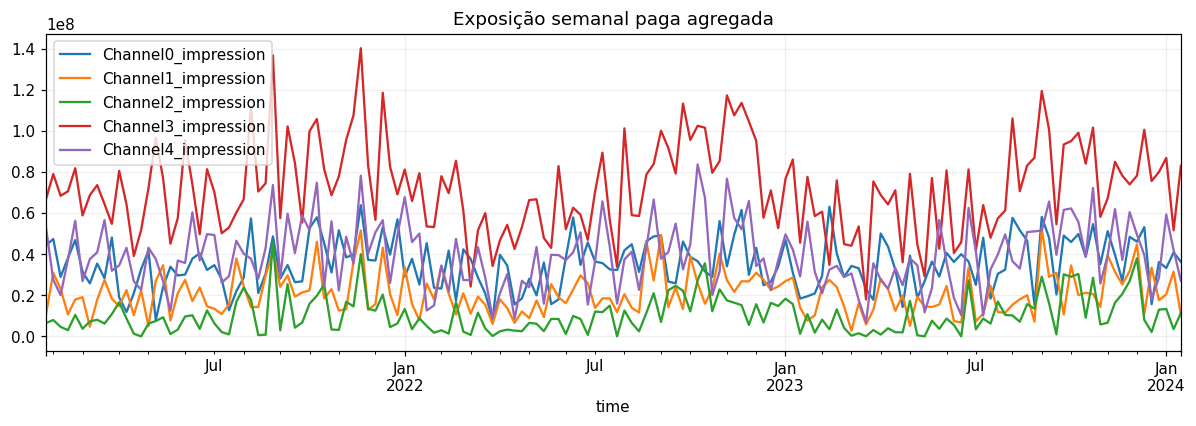

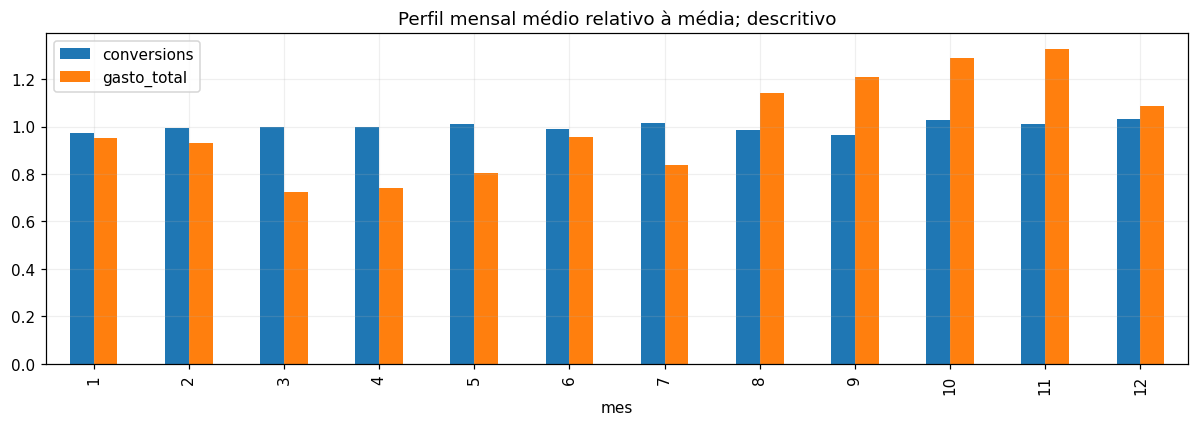

,conversions,gasto_total
1,0.007826,0.371276
2,0.050372,0.271458
3,0.049952,0.428684
4,0.030371,0.320157
5,-0.059937,0.338326
6,0.026467,0.364492
7,0.017256,0.286505
8,0.011163,0.177789
9,-0.096296,0.148742
10,-0.153683,0.157118


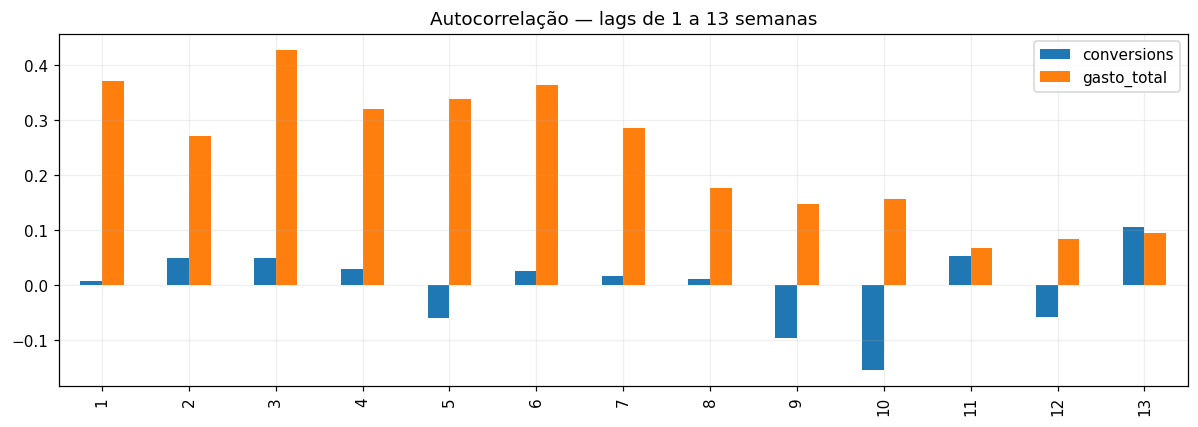

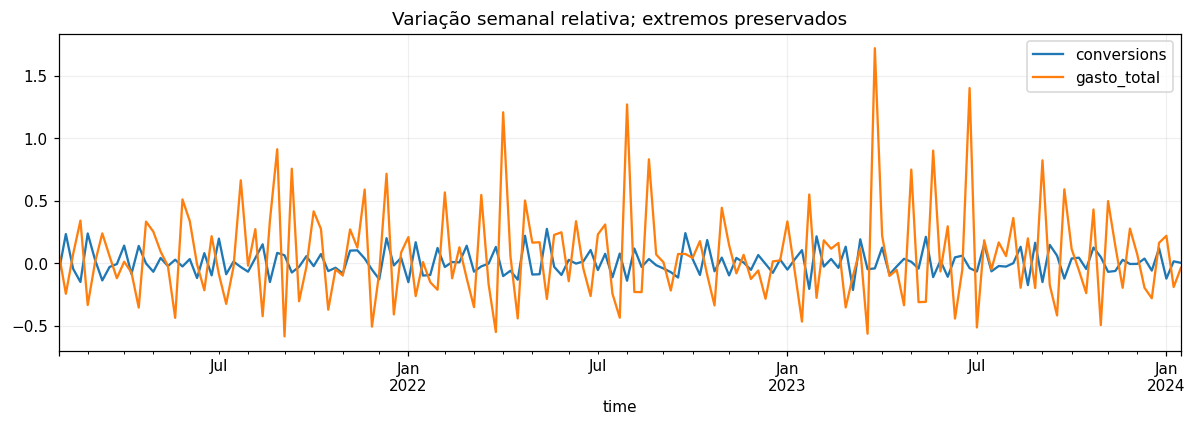

In [5]:
weekly = df.groupby('time')[['conversions','receita_sintetica','gasto_total']+paid+organic].sum()
table(weekly.describe().T,'resumo_semanal')
weekly[['conversions','gasto_total']].div(weekly[['conversions','gasto_total']].iloc[0]).mul(100).plot(title='KPI e gasto — índice da primeira semana = 100'); show('series_indices')
weekly[paid].plot(title='Exposição semanal paga agregada'); show('exposicao_semanal')
monthly=weekly.assign(mes=weekly.index.month).groupby('mes')[['conversions','gasto_total']].mean()
monthly.div(monthly.mean()).plot.bar(title='Perfil mensal médio relativo à média; descritivo'); show('perfil_mensal')
acf=pd.DataFrame({c:[weekly[c].autocorr(lag=l) for l in range(1,14)] for c in ['conversions','gasto_total']}, index=range(1,14))
table(acf,'autocorrelacao_semanal'); acf.plot.bar(title='Autocorrelação — lags de 1 a 13 semanas'); show('acf')
weekly[['conversions','gasto_total']].pct_change().dropna().plot(title='Variação semanal relativa; extremos preservados'); show('variacoes_semanais')


## 5. Heterogeneidade regional e informação dentro de cada região
Uma região grande pode ter mais anúncios e mais conversões simplesmente por tamanho. Comparamos valores brutos e por habitante e medimos variabilidade temporal por região. Normalização aqui é diagnóstico; o Meridian possui transformações próprias e não deve receber dados pré-normalizados sem uma decisão explícita.


,populacao,conversoes,receita,gasto,conversoes_por_habitante_semana,gasto_por_habitante_semana,participacao_gasto_pct
geo,,,,,,,
Geo23,981570.90,2.836450e+09,5.673184e+07,9.937170e+06,18.523747,0.064896,4.527341
Geo36,969886.50,3.290565e+09,6.581648e+07,9.761024e+06,21.748281,0.064513,4.447090
Geo10,994048.94,3.093954e+09,6.191079e+07,9.680096e+06,19.951773,0.062423,4.410219
Geo2,892369.50,2.468820e+09,4.937024e+07,9.432803e+06,17.734549,0.067760,4.297553
Geo31,873369.70,2.684670e+09,5.367754e+07,8.667995e+06,19.704624,0.063620,3.949109
Geo17,777539.94,2.201843e+09,4.408524e+07,8.022049e+06,18.152607,0.066136,3.654819
Geo14,765448.10,2.103735e+09,4.207460e+07,8.014070e+06,17.617764,0.067114,3.651183
Geo25,779181.90,2.437115e+09,4.872741e+07,7.990459e+06,20.049917,0.065737,3.640426
Geo35,742166.56,2.058954e+09,4.117710e+07,7.816732e+06,17.783640,0.067515,3.561277


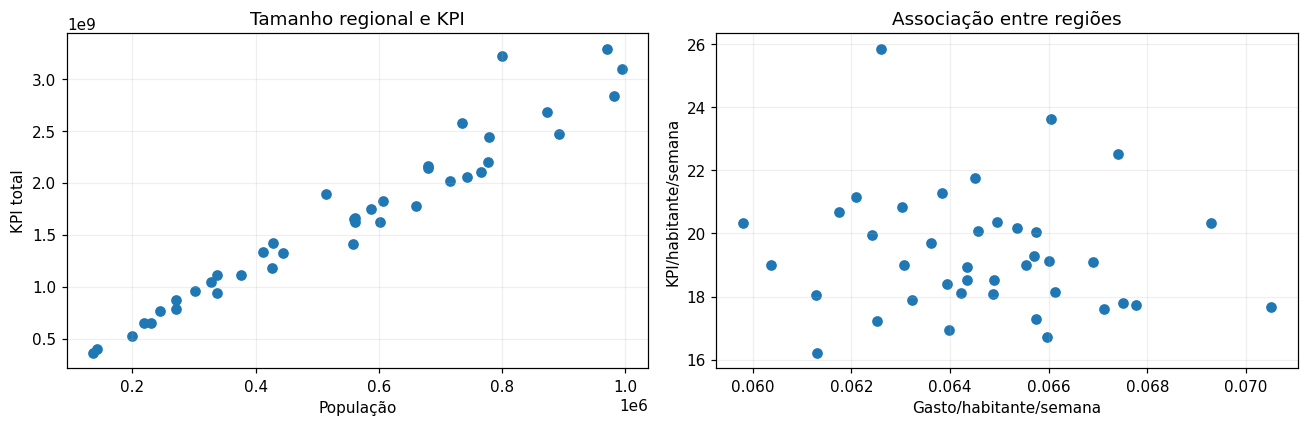

,Channel0_impression,Channel1_impression,Channel2_impression,Channel3_impression,Channel4_impression,conversions
geo,,,,,,
Geo0,0.725693,0.972468,1.815097,0.496042,0.784149,0.335436
Geo1,0.741248,0.987051,1.823280,0.577049,0.777135,0.493861
Geo10,0.750405,1.022251,1.959942,0.500901,0.699021,0.321279
Geo11,0.778875,1.013479,1.783769,0.491928,0.754813,0.301804
Geo12,0.740733,1.018644,1.885194,0.542861,0.787164,0.289723
Geo13,0.751774,0.922994,1.965914,0.538546,0.718700,0.394158
Geo14,0.810384,0.937667,1.783504,0.500536,0.728493,0.355247
Geo15,0.770349,0.978331,1.756129,0.524680,0.666030,0.288884
Geo16,0.692119,1.174901,2.000061,0.505167,0.728502,0.306761


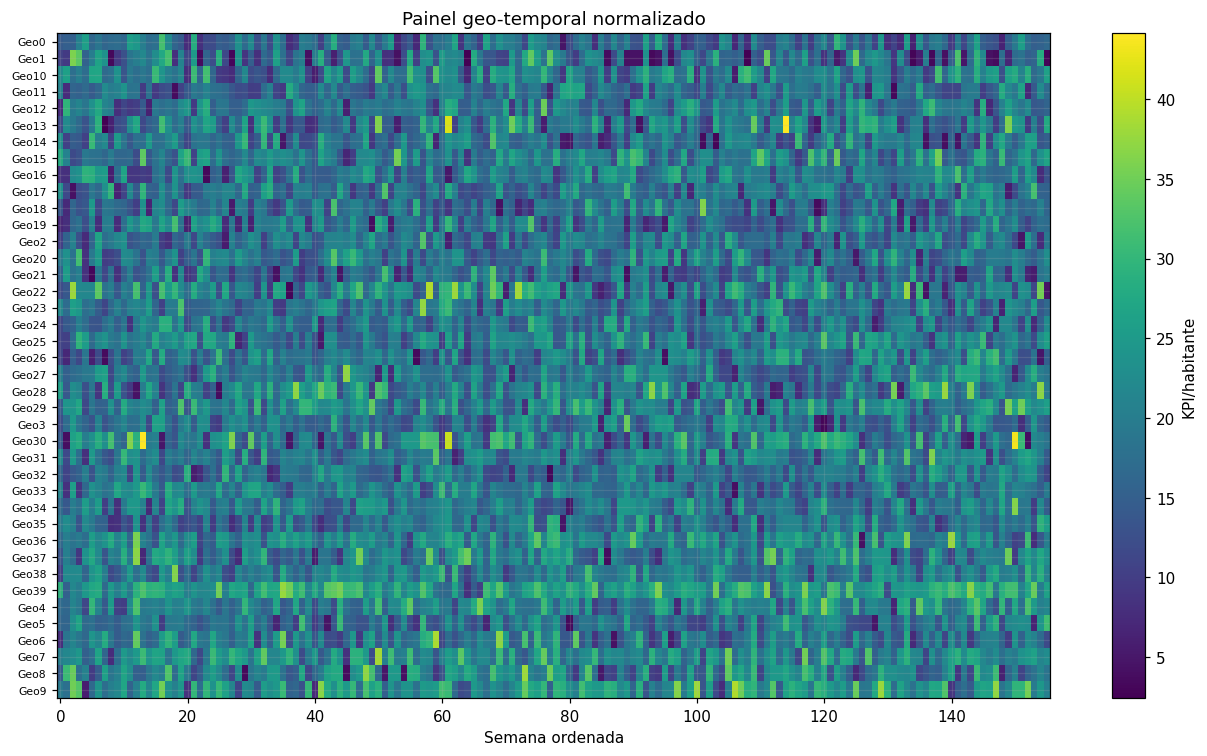

In [6]:
geo = df.groupby('geo').agg(populacao=('population','first'), conversoes=('conversions','sum'), receita=('receita_sintetica','sum'), gasto=('gasto_total','sum'))
geo['conversoes_por_habitante_semana']=geo.conversoes/geo.populacao/df.time.nunique()
geo['gasto_por_habitante_semana']=geo.gasto/geo.populacao/df.time.nunique()
geo['participacao_gasto_pct']=100*geo.gasto/geo.gasto.sum()
table(geo.sort_values('gasto',ascending=False),'regioes')
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].scatter(geo.populacao,geo.conversoes); axes[0].set(xlabel='População',ylabel='KPI total',title='Tamanho regional e KPI')
axes[1].scatter(geo.gasto_por_habitante_semana,geo.conversoes_por_habitante_semana); axes[1].set(xlabel='Gasto/habitante/semana',ylabel='KPI/habitante/semana',title='Associação entre regiões')
show('heterogeneidade')
within_cv=df.groupby('geo')[paid+['conversions']].std()/df.groupby('geo')[paid+['conversions']].mean()
table(within_cv,'cv_temporal_por_geo')
heat=df.assign(kpi_pc=df.conversions/df.population).pivot(index='geo',columns='time',values='kpi_pc')
plt.figure(figsize=(12,7)); plt.imshow(heat,aspect='auto',cmap='viridis'); plt.yticks(range(len(heat)),heat.index,fontsize=7); plt.xlabel('Semana ordenada'); plt.colorbar(label='KPI/habitante'); plt.title('Painel geo-temporal normalizado'); show('painel_geo')


## 6. Correlações, confundimento e redundância
Comparamos Pearson, Spearman, associação nacional e associações dentro de regiões. A transformação com efeitos de região e semana subtraídos é apenas um diagnóstico de covariação residual em painel balanceado; não estima causalidade.
VIF sinaliza dependência linear entre entradas; valores elevados podem dificultar separar canais. Não removemos variáveis causais automaticamente por VIF.
Defasagens sempre são feitas dentro de cada região para não conectar o fim de uma série ao início de outra.


,Pearson_bruto,Spearman_bruto,Pearson_per_capita,dentro_geo_per_capita,efeitos_geo_semana_removidos
Channel0_impression,0.413823,0.391162,0.024409,0.022903,0.026467
Channel1_impression,0.293146,0.216685,-0.026540,-0.025474,-0.025638
Channel2_impression,0.147900,0.028490,-0.090166,-0.092849,-0.080996
Channel3_impression,0.468854,0.495735,-0.102851,-0.103153,-0.092035
Channel4_impression,0.348243,0.320141,-0.118600,-0.125158,-0.112693
Organic_channel0_impression,0.298234,0.197257,-0.014055,-0.009020,0.002065
competitor_sales_control,-0.116719,-0.108706,-0.247793,-0.255233,-0.235971
sentiment_score_control,-0.009457,-0.011911,-0.056929,-0.056487,-0.047212
Promo,0.080219,0.075492,0.128771,0.139800,0.126617
conversions,1.000000,1.000000,1.000000,1.000000,1.000000


,Channel0_impression,Channel1_impression,Channel2_impression,Channel3_impression,Channel4_impression,conversions
Channel0_impression,1.000000,0.326064,0.384733,0.436695,0.268249,0.051404
Channel1_impression,0.326064,1.000000,0.427646,0.450875,0.373587,0.012076
Channel2_impression,0.384733,0.427646,1.000000,0.700285,0.642452,-0.110366
Channel3_impression,0.436695,0.450875,0.700285,1.000000,0.615033,-0.123964
Channel4_impression,0.268249,0.373587,0.642452,0.615033,1.000000,-0.178786
conversions,0.051404,0.012076,-0.110366,-0.123964,-0.178786,1.000000


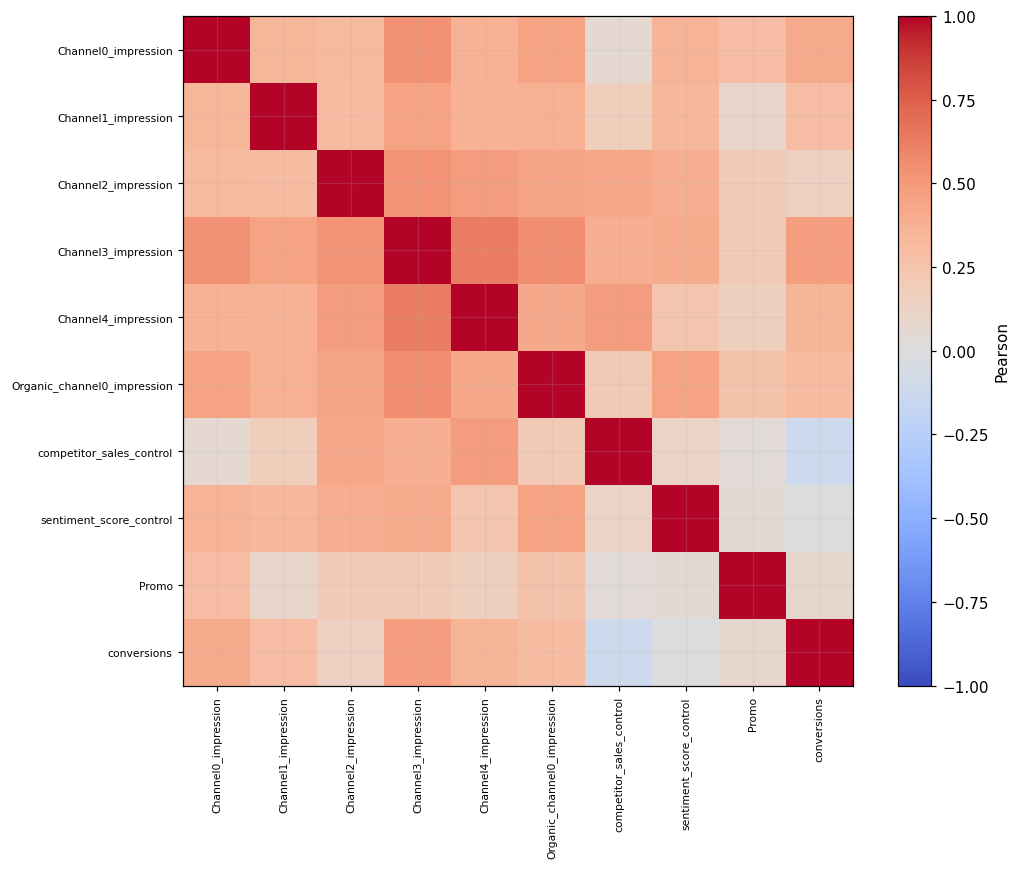

,VIF
variavel,
Channel0_impression,1.458924
Channel1_impression,1.228402
Channel2_impression,1.719062
Channel3_impression,2.456486
Channel4_impression,1.773253
Organic_channel0_impression,1.632197
competitor_sales_control,2.414789
sentiment_score_control,2.597378
Promo,1.493650


,canal,lag_semanas,corr_descritiva,pares
0,Channel0_impression,0,0.024409,6240
1,Channel0_impression,1,0.008693,6200
2,Channel0_impression,2,0.015265,6160
3,Channel0_impression,3,-0.006051,6120
4,Channel0_impression,4,0.009831,6080
5,Channel0_impression,5,0.019004,6040
6,Channel0_impression,6,0.011408,6000
7,Channel0_impression,7,0.024651,5960
8,Channel0_impression,8,-0.003154,5920
9,Channel1_impression,0,-0.026540,6240


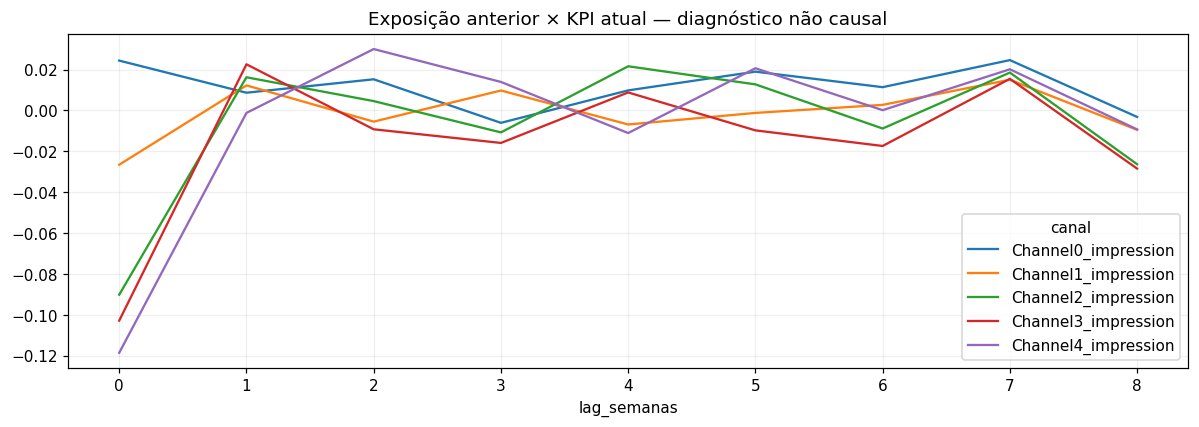

In [7]:
features=paid+organic+controls+['Promo']
cols=features+['conversions']
raw=df[cols].corr(); rank=df[cols].corr(method='spearman')
percap=df[cols].copy()
for c in paid+organic+['conversions']: percap[c]=percap[c]/df.population
within=percap-percap.groupby(df.geo).transform('mean')
twoway=within-percap.groupby(df.time).transform('mean')+percap.mean()
table(pd.DataFrame({'Pearson_bruto':raw.conversions, 'Spearman_bruto':rank.conversions, 'Pearson_per_capita':percap.corr().conversions, 'dentro_geo_per_capita':within.corr().conversions, 'efeitos_geo_semana_removidos':twoway.corr().conversions}), 'correlacoes_kpi')
table(weekly[paid+['conversions']].corr(),'correlacao_nacional')
plt.figure(figsize=(10,8)); plt.imshow(raw,vmin=-1,vmax=1,cmap='coolwarm'); plt.xticks(range(len(cols)),cols,rotation=90,fontsize=7); plt.yticks(range(len(cols)),cols,fontsize=7); plt.colorbar(label='Pearson'); show('correlacao_bruta')
def vif_frame(X):
    X=(X-X.mean())/X.std(ddof=0)
    results=[]
    for c in X:
        y=X[c].to_numpy(); others=X.drop(columns=c).to_numpy()
        fit=np.column_stack([np.ones(len(y)),others]); beta=np.linalg.lstsq(fit,y,rcond=None)[0]
        r2=1-np.sum((y-fit@beta)**2)/np.sum((y-y.mean())**2)
        results.append({'variavel':c,'VIF':1/max(1-r2,1e-12)})
    return pd.DataFrame(results).set_index('variavel')
table(vif_frame(percap[features]),'vif_per_capita')
lagrows=[]
for c in paid:
    for lag in range(9):
        shifted=percap[c].groupby(df.geo).shift(lag)
        lagrows.append({'canal':c,'lag_semanas':lag,'corr_descritiva':shifted.corr(percap.conversions),'pares':int(shifted.notna().sum())})
lags=pd.DataFrame(lagrows); table(lags,'correlacoes_defasadas')
lags.pivot(index='lag_semanas',columns='canal',values='corr_descritiva').plot(title='Exposição anterior × KPI atual — diagnóstico não causal'); show('lags')


## 7. Suporte de dose, mídia orgânica e promoções
Agrupamos exposição em quantis para inspecionar suporte. Curvatura em um gráfico observacional não demonstra saturação: pode refletir região, calendário, promoções ou endogeneidade. As curvas Hill serão estimadas na etapa Bayesiana.
Mídia orgânica tem exposição mas nenhum gasto próprio no arquivo; não se calcula ROI orgânico com denominador zero.
Comparar semanas com e sem promoções não é um experimento aleatorizado.


Promo varia de 0.0 a 4.8005548 ; fração positiva: 0.5317307692307692
Mídia orgânica: zeros (%): 33.253205128205124


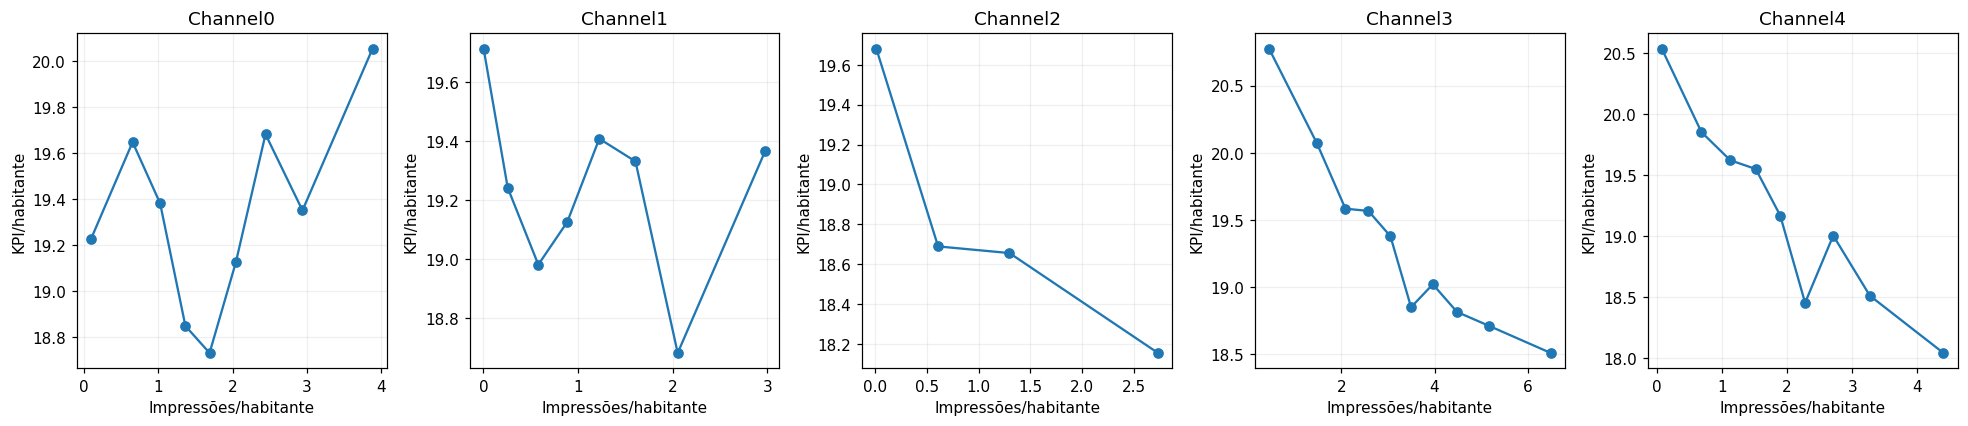

,exposicao_pc,kpi_pc,n,canal
0,0.090009,19.224959,1248,Channel0_impression
1,0.652038,19.648020,624,Channel0_impression
2,1.022943,19.381373,624,Channel0_impression
3,1.363486,18.847501,624,Channel0_impression
4,1.688966,18.729824,624,Channel0_impression
5,2.043370,19.124777,624,Channel0_impression
6,2.442881,19.682248,624,Channel0_impression
7,2.940813,19.350602,624,Channel0_impression
8,3.885569,20.055222,624,Channel0_impression
9,0.002693,19.713099,1872,Channel1_impression


,n,kpi_pc_medio,intensidade_media
promo_ativa,,,
False,2922,18.759981,0.000000
True,3318,19.826249,0.926273


In [8]:
support=[]
fig,axes=plt.subplots(1,len(paid),figsize=(18,4))
for ax,c in zip(axes,paid):
    tmp=pd.DataFrame({'x':df[c]/df.population,'y':df.conversions/df.population})
    tmp['bin']=pd.qcut(tmp.x,10,duplicates='drop')
    b=tmp.groupby('bin',observed=True).agg(exposicao_pc=('x','mean'),kpi_pc=('y','mean'),n=('y','size')).reset_index(drop=True)
    b['canal']=c; support.append(b); ax.plot(b.exposicao_pc,b.kpi_pc,'o-'); ax.set(title=c.replace('_impression',''),xlabel='Impressões/habitante',ylabel='KPI/habitante')
show('dose_observacional'); table(pd.concat(support,ignore_index=True),'suporte_quantils')
promo=df.assign(promo_ativa=df.Promo.gt(0),kpi_pc=df.conversions/df.population).groupby('promo_ativa').agg(n=('conversions','size'),kpi_pc_medio=('kpi_pc','mean'),intensidade_media=('Promo','mean'))
table(promo,'promo_descritivo')
print('Promo varia de',df.Promo.min(),'a',df.Promo.max(),'; fração positiva:',df.Promo.gt(0).mean())
print('Mídia orgânica: zeros (%):',100*df[organic[0]].eq(0).mean())


## 8. Cenário separado de alcance e frequência
`geo_media_rf.csv` não é uma extensão linha a linha da base principal. Channel3 possui alcance e frequência. Verificamos impressões ≈ alcance × frequência e alcance ≤ população.
Alcance pode ser somado entre regiões disjuntas na mesma semana; não some semanas como se obtivesse pessoas únicas. Frequência nacional requer ponderação pelo alcance, nunca média simples das frequências.
Na futura carga do Meridian, Channel3 deve entrar pelo grupo reach/frequency/rf_spend; não duplicar o canal também em media/media_spend.


,valor
max_erro_absoluto_impressao,2.009960e-01
max_erro_relativo_ativo,1.022142e-07
alcance_maior_populacao,0.000000e+00
freq_negativa,0.000000e+00
zeros_rf_inconsistentes,0.000000e+00


,count,mean,std,min,25%,50%,75%,max
alcance,156.0,5.855227e+06,2.059153e+06,566746.000000,4.701708e+06,6.153934e+06,7.418022e+06,9.411511e+06
impressoes,156.0,1.069993e+07,5.167884e+06,658645.000000,7.121242e+06,1.070231e+07,1.410313e+07,2.465684e+07
frequencia_ponderada,156.0,1.734201e+00,2.891802e-01,1.162152,1.505172e+00,1.720860e+00,1.907280e+00,2.624090e+00


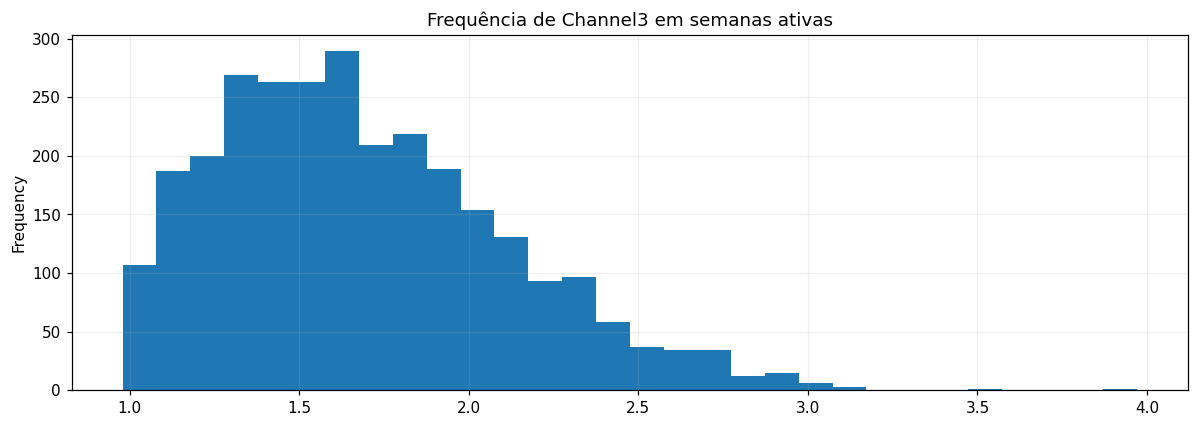

In [9]:
rf=datasets['geo_media_rf']
reconstructed=rf.Channel3_reach*rf.Channel3_frequency
active=rf.Channel3_impression.gt(0)
rfchecks=pd.Series({'max_erro_absoluto_impressao':(reconstructed-rf.Channel3_impression).abs().max(),'max_erro_relativo_ativo':((reconstructed[active]-rf.loc[active,'Channel3_impression']).abs()/rf.loc[active,'Channel3_impression']).max(),'alcance_maior_populacao':int(rf.Channel3_reach.gt(rf.population).sum()),'freq_negativa':int(rf.Channel3_frequency.lt(0).sum()),'zeros_rf_inconsistentes':int((rf.Channel3_reach.eq(0)!=rf.Channel3_frequency.eq(0)).sum())})
table(rfchecks.to_frame('valor'),'auditoria_rf')
rfsummary=rf.groupby('time').agg(alcance=('Channel3_reach','sum'),impressoes=('Channel3_impression','sum'))
rfsummary['frequencia_ponderada']=rfsummary.impressoes/rfsummary.alcance.replace(0,np.nan)
table(rfsummary.describe().T,'resumo_rf')
rf.loc[active,'Channel3_frequency'].plot.hist(bins=30,title='Frequência de Channel3 em semanas ativas'); show('frequencia_rf')


## 9. Preparação de avaliação e próximos passos
Separamos as últimas 26 semanas como proposta de holdout temporal comum a todas as regiões. Não utilizamos embaralhamento aleatório. Na modelagem, tuning, priors orientadas por dados e transformações aprendidas devem usar apenas treino. Valores anteriores de mídia podem ser necessários como histórico para carryover; o CSV começa junto com o KPI, sem pré-histórico de exposição.
A comparação abaixo descreve mudança de suporte. Não é desempenho preditivo, pois nenhum modelo foi ajustado.

O CSV não contém nomes reais de canais, preço de produto, GQV, experimento de incrementalidade, mecanismo causal completo ou parâmetros verdadeiros do gerador. Assim, não permite identificar um caso de Paid Search nem validar recuperação de ROI verdadeiro só com esses arquivos.

Próximas etapas: DAG e premissas; ingestão no Meridian; baseline e priors alternativas; prior predictive checks; MCMC e diagnósticos R-hat/ESS/divergências; posterior predictive checks e holdout; contribuição/ROI com incerteza; curvas de resposta e mROI; otimização com limites e sensibilidade. Bom ajuste preditivo não prova identificação causal.


In [10]:
times=np.sort(df.time.unique()); split=pd.Timestamp(times[-26])
df['holdout']=df.time.ge(split)
comparison=df.groupby('holdout')[['conversions','gasto_total']+paid+controls+['Promo']].agg(['mean','std','min','max'])
table(comparison,'treino_holdout_descritivo')
print('Holdout a partir de',split.date(),'; treino:',(~df.holdout).sum(),'; teste:',df.holdout.sum())
# CSV limpo preserva unidades originais e não inclui variáveis derivadas para o loader.
original_cols=datasets['geo_all_channels'].columns
clean=df[original_cols].copy(); clean['time']=clean.time.dt.strftime('%Y-%m-%d')
clean.to_csv(OUT/'geo_all_channels_clean.csv',index=False)
# Máscara por coordenadas explicitamente ordenadas, para futura construção do ModelSpec.
mask=df.pivot(index='geo',columns='time',values='holdout').sort_index().sort_index(axis=1)
mask.to_csv(OUT/'holdout_geo_time.csv')
print('Tabelas e figuras disponíveis em:',OUT)


Holdout a partir de 2023-07-24 ; treino: 5200 ; teste: 1040
Tabelas e figuras disponíveis em: /workspace/scratch/a627c0f89ab3/meridian_project/reports/eda


conversions                                        gasto_total  \
                 mean           std        min         max          mean   
holdout                                                                    
False    1.053215e+07  6.037721e+06  484031.22  36712692.0  33993.090657   
True     1.073415e+07  6.283988e+06  582637.90  36644916.0  41084.933588   

                                       Channel0_impression                     \
                  std  min         max                mean            std min   
holdout                                                                         
False    24911.289852  0.0  184340.343        8.579255e+05  801953.148542   0   
True     26857.060325  0.0  146985.836        1.021354e+06  889264.040289   0   

                 Channel1_impression                     ...  \
             max                mean            std min  ...   
holdout                                                  ...   
False    5192032       506499.070192  610267.353770   0  ...   
True     4658004       591137.892308  665846.505597   0  ...   

        Channel4_impression              competitor_sales_control            \
                        std min      max                     mean       std   
holdout                                                                       
False         905050.548622   0  6975542                -0.113345  1.213941   
True          940758.022743   0  5295219                 0.300255  1.130222   

                            sentiment_score_control                      \
              min       max                    mean       std       min   
holdout                                                                   
False   -4.825634  3.924682               -0.079761  1.176118 -4.230392   
True    -2.789767  3.763116                0.196753  1.145908 -3.555376   

                      Promo                           
              max      mean       std  min       max  
holdout                                               
False    4.320259  0.458992  0.668926  0.0  4.800555  
True     3.980857  0.660208  0.788454  0.0  3.942986  

[2 rows x 40 columns]

## 10. Ajustes conceituais recomendados para o texto do TCC
1. Priors hierárquicas e mais regiões não garantem identificação causal; esta depende das premissas e dos confundidores medidos.
2. O parâmetro de meia-saturação da Hill marca H(x)=0,5; não é, em geral, o ponto de inflexão (e curvas em C podem não ter inflexão interior).
3. A recursão de adstock do referencial é uma representação didática. Compare-a com a transformação efetiva e a janela finita/normalização do Meridian antes de atribuir equivalência.
4. Esclareça ROI como receita incremental/gasto na convenção do Meridian; isso não é lucro líquido nem a fórmula financeira (retorno-custo)/custo.
5. O caráter sintético sustenta demonstração metodológica. Validação de recuperação de parâmetros exige verdade conhecida e gerador documentado, além de múltiplas simulações.

Fontes: [repositório oficial](https://github.com/google/meridian), [guia de carga completa](https://developers.google.com/meridian/docs/user-guide/load-geo-data-with-organic-and-non-media), [guia de alcance/frequência](https://developers.google.com/meridian/docs/user-guide/load-geo-data-with-rf). Consultadas em 30/09/2026. Esquema e estatísticas conferidos diretamente nos CSVs do commit fixado.
